# Online Retail Dataset — Basic Stats & Data Quality

Load the dataset and inspect structure, basic statistics, and data quality issues.

In [65]:
import pandas as pd
import numpy as np

# Load the Online Retail dataset
df = pd.read_excel("Online Retail.xlsx")
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


## 1. Basic statistics

In [66]:
# Shape and column info
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:\n", df.dtypes)

Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
 InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


In [67]:
# Numeric summary
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [68]:
# Key counts (invoices, products, customers, countries)
key_cols = [c for c in df.columns if c in ("InvoiceNo", "StockCode", "Description", "CustomerID", "Country")]
for col in key_cols:
    if col in df.columns:
        n_unique = df[col].nunique()
        print(f"{col}: {n_unique:,} unique values")

InvoiceNo: 25,900 unique values
StockCode: 4,070 unique values
Description: 4,223 unique values
CustomerID: 4,372 unique values
Country: 38 unique values


## 2. Data quality observations

In [69]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality = pd.DataFrame({"Missing": missing, "Missing %": missing_pct})
quality[quality["Missing"] > 0].sort_values("Missing", ascending=False)

,Missing,Missing %
CustomerID,135080,24.93
Description,1454,0.27


In [70]:
# Duplicate rows and invalid values
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes:,} ({100*n_dupes/len(df):.2f}%)")

# Check for invalid numeric values (Quantity, UnitPrice)
if "Quantity" in df.columns:
    neg_qty = (df["Quantity"] <= 0).sum()
    print(f"\nQuantity <= 0: {neg_qty:,} rows")
if "UnitPrice" in df.columns:
    neg_price = (df["UnitPrice"] < 0).sum()
    zero_price = (df["UnitPrice"] == 0).sum()
    print(f"UnitPrice < 0: {neg_price:,} rows")
    print(f"UnitPrice == 0: {zero_price:,} rows")

Duplicate rows: 5,268 (0.97%)

Quantity <= 0: 10,624 rows
UnitPrice < 0: 2 rows
UnitPrice == 0: 2,515 rows


In [71]:
# Invoice numbers: cancellations often start with 'C'
if "InvoiceNo" in df.columns:
    inv = df["InvoiceNo"].astype(str)
    cancellations = inv.str.startswith("C", na=False)
    print(f"Invoice lines that look like cancellations (start with 'C'): {cancellations.sum():,}")

Invoice lines that look like cancellations (start with 'C'): 9,288


In [72]:
# Summary: data quality snapshot
print("=== DATA QUALITY SUMMARY ===\n")
print(f"Total rows: {len(df):,}")
print(f"Missing CustomerID: {df['CustomerID'].isna().sum():,} ({100*df['CustomerID'].isna().sum()/len(df):.1f}%)")
print(f"Duplicate rows: {df.duplicated().sum():,}")
if "Quantity" in df.columns:
    print(f"Invalid Quantity (<=0): {(df['Quantity'] <= 0).sum():,}")
if "UnitPrice" in df.columns:
    print(f"Invalid UnitPrice (<0): {(df['UnitPrice'] < 0).sum():,}")
print("\nImmediate observations:")
print("- Consider dropping or imputing rows with missing CustomerID for customer-level analysis.")
print("- Remove or flag duplicate rows and rows with Quantity<=0 or UnitPrice<0 before revenue/quantity metrics.")
print("- Treat cancellation invoices (InvoiceNo starting with 'C') separately in analysis.")

=== DATA QUALITY SUMMARY ===

Total rows: 541,909
Missing CustomerID: 135,080 (24.9%)
Duplicate rows: 5,268
Invalid Quantity (<=0): 10,624
Invalid UnitPrice (<0): 2

Immediate observations:
- Consider dropping or imputing rows with missing CustomerID for customer-level analysis.
- Remove or flag duplicate rows and rows with Quantity<=0 or UnitPrice<0 before revenue/quantity metrics.
- Treat cancellation invoices (InvoiceNo starting with 'C') separately in analysis.


In [73]:
# ==============================
# Cleaning + Revenue + Before/After stats
# ==============================

# Keep an untouched copy for "before" stats
raw = df.copy()

# Helper to print key dataset statistics
def dataset_stats(label: str, d: pd.DataFrame) -> None:
    inv = d["InvoiceNo"].astype(str) if "InvoiceNo" in d.columns else pd.Series(dtype=str)
    cancellations = inv.str.startswith("C", na=False) if len(inv) else pd.Series([False] * len(d))

    dupes = d.duplicated().sum()
    missing_total = int(d.isna().sum().sum())
    missing_by_col = d.isna().sum().to_dict()

    qty_le0 = int((d["Quantity"] <= 0).sum()) if "Quantity" in d.columns else 0
    price_le0 = int((d["UnitPrice"] <= 0).sum()) if "UnitPrice" in d.columns else 0

    revenue_sum = float(d["Revenue"].sum()) if "Revenue" in d.columns else np.nan
    revenue_mean = float(d["Revenue"].mean()) if "Revenue" in d.columns else np.nan

    print(f"\n=== {label} ===")
    print(f"Rows: {len(d):,}")
    if "InvoiceNo" in d.columns:
        print(f"Unique invoices: {d['InvoiceNo'].nunique():,}")
    if "CustomerID" in d.columns:
        print(f"Unique customers: {d['CustomerID'].nunique(dropna=True):,}")
    if "Country" in d.columns:
        print(f"Unique countries: {d['Country'].nunique():,}")

    print(f"Duplicate rows: {dupes:,}")
    print(f"Missing values (total cells): {missing_total:,}")
    print("Missing by column:")
    for k, v in missing_by_col.items():
        if v:
            print(f"  - {k}: {int(v):,}")

    if "InvoiceNo" in d.columns:
        print(f"Cancellation-looking lines (InvoiceNo starts with 'C'): {int(cancellations.sum()):,}")
    if "Quantity" in d.columns:
        print(f"Quantity <= 0: {qty_le0:,}")
    if "UnitPrice" in d.columns:
        print(f"UnitPrice <= 0: {price_le0:,}")

    if "Revenue" in d.columns:
        print(f"Revenue sum: £{revenue_sum:,.2f}")
        print(f"Revenue mean: £{revenue_mean:,.4f}")


# BEFORE stats
dataset_stats("BEFORE (raw)", raw)

# --- Cleaning rules ---
# 1) Remove exact duplicate rows
clean = raw.drop_duplicates().copy()

# 2) Remove missing values (focus on key analysis columns)
required_cols = [c for c in ["CustomerID", "Description", "InvoiceNo", "StockCode", "InvoiceDate", "Quantity", "UnitPrice", "Country"] if c in clean.columns]
clean = clean.dropna(subset=required_cols).copy()

# 3) Handle cancelled/returned transactions
#    - Cancelled invoices often start with 'C'
#    - Returns/corrections often have Quantity <= 0
inv = clean["InvoiceNo"].astype(str)
cancel_mask = inv.str.startswith("C", na=False)
clean = clean.loc[~cancel_mask].copy()

# Remove non-positive quantities and non-positive prices for sales-only analytics
clean = clean.loc[(clean["Quantity"] > 0) & (clean["UnitPrice"] > 0)].copy()

# 4) Create Revenue column
clean["Revenue"] = clean["Quantity"] * clean["UnitPrice"]

# Optional: cast CustomerID to int for cleaner joins/groupbys
# (safe now because missing CustomerID rows were removed)
clean["CustomerID"] = clean["CustomerID"].astype(int)

# AFTER stats
dataset_stats("AFTER (clean)", clean)

# Preview cleaned dataset
clean.head(5)


=== BEFORE (raw) ===
Rows: 541,909
Unique invoices: 25,900
Unique customers: 4,372
Unique countries: 38
Duplicate rows: 5,268
Missing values (total cells): 136,534
Missing by column:
  - Description: 1,454
  - CustomerID: 135,080
Cancellation-looking lines (InvoiceNo starts with 'C'): 9,288
Quantity <= 0: 10,624
UnitPrice <= 0: 2,517

=== AFTER (clean) ===
Rows: 392,692
Unique invoices: 18,532
Unique customers: 4,338
Unique countries: 37
Duplicate rows: 0
Missing values (total cells): 0
Missing by column:
Cancellation-looking lines (InvoiceNo starts with 'C'): 0
Quantity <= 0: 0
UnitPrice <= 0: 0
Revenue sum: £8,887,208.89
Revenue mean: £22.6315


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## E-commerce analysis

Sales & revenue trends, geographic distribution, top products, and average order value (using cleaned data).

### Summary of main insights (from run results)
- **Sales & revenue over time:** Revenue grows into late 2011; Nov 2011 is the peak (~£1.16M revenue, 2,657 orders). Dec 2011 is partial (~£517K). Strong seasonality (Q4 spike).
- **Geography:** UK dominates (~82% of revenue, £7.29M). Netherlands, EIRE, Germany, France next; Netherlands and Australia have very high average order value (£3K+).
- **Top products:** PAPER CRAFT LITTLE BIRDIE leads by revenue (£168K); REGENCY CAKESTAND 3 TIER, WHITE HANGING HEART T-LIGHT HOLDER, JUMBO BAG RED RETROSPOT, POSTAGE and party/decoration items are top drivers.
- **Average order value:** Mean AOV £479.56, median £302.57 — distribution is right‑skewed; many small baskets, fewer large ones.

In [74]:
# Sales & revenue trends over time (monthly)
clean["YearMonth"] = clean["InvoiceDate"].dt.to_period("M")
trends = clean.groupby("YearMonth").agg(
    Revenue=("Revenue", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Items=("Quantity", "sum"),
).reset_index()
trends["YearMonth"] = trends["YearMonth"].astype(str)
print("Monthly sales & revenue trends")
display(trends.style.format({"Revenue": "£{:,.2f}"}))

Monthly sales & revenue trends


,YearMonth,Revenue,Orders,Items
0,2010-12,"£570,422.73",1400,311048
1,2011-01,"£568,101.31",987,348473
2,2011-02,"£446,084.92",997,265027
3,2011-03,"£594,081.76",1321,347582
4,2011-04,"£468,374.33",1149,291366
5,2011-05,"£677,355.15",1555,372864
6,2011-06,"£660,046.05",1393,363014
7,2011-07,"£598,962.90",1331,367360
8,2011-08,"£644,051.04",1280,397373
9,2011-09,"£950,690.20",1755,543652


In [75]:
# Geographic distribution: revenue, sales (order count), and avg order value by country
order_value = clean.groupby("InvoiceNo").agg(OrderRevenue=("Revenue", "sum")).reset_index()
order_value = order_value.merge(
    clean[["InvoiceNo", "Country"]].drop_duplicates(), on="InvoiceNo", how="left"
)
geo = order_value.groupby("Country").agg(
    Revenue=("OrderRevenue", "sum"),
    Orders=("InvoiceNo", "nunique"),
).reset_index()
geo["AvgOrderValue"] = geo["Revenue"] / geo["Orders"]
geo = geo.sort_values("Revenue", ascending=False).reset_index(drop=True)
print("Revenue, order count, and average order value by country")
display(geo.style.format({"Revenue": "£{:,.2f}", "AvgOrderValue": "£{:,.2f}"}))

Revenue, order count, and average order value by country


,Country,Revenue,Orders,AvgOrderValue
0,United Kingdom,"£7,285,024.64",16646,£437.64
1,Netherlands,"£285,446.34",94,"£3,036.66"
2,EIRE,"£265,262.46",260,"£1,020.24"
3,Germany,"£228,678.40",457,£500.39
4,France,"£208,934.31",389,£537.11
5,Australia,"£138,453.81",57,"£2,429.01"
6,Spain,"£61,558.56",90,£683.98
7,Switzerland,"£56,443.95",51,"£1,106.74"
8,Belgium,"£41,196.34",98,£420.37
9,Sweden,"£38,367.83",36,"£1,065.77"


In [76]:
# Top performing products (by revenue and by quantity)
top_products = clean.groupby(["StockCode", "Description"]).agg(
    Revenue=("Revenue", "sum"),
    Quantity=("Quantity", "sum"),
    Orders=("InvoiceNo", "nunique"),
).reset_index()
top_by_revenue = top_products.nlargest(20, "Revenue").reset_index(drop=True)
top_by_quantity = top_products.nlargest(20, "Quantity").reset_index(drop=True)
print("Top 20 products by revenue")
display(top_by_revenue.style.format({"Revenue": "£{:,.2f}"}))
print("Top 20 products by quantity sold")
display(top_by_quantity.style.format({"Revenue": "£{:,.2f}"}))

Top 20 products by revenue


,StockCode,Description,Revenue,Quantity,Orders
0,23843,"PAPER CRAFT , LITTLE BIRDIE","£168,469.60",80995,1
1,22423,REGENCY CAKESTAND 3 TIER,"£142,264.75",12374,1703
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"£100,392.10",36706,1971
3,85099B,JUMBO BAG RED RETROSPOT,"£85,040.54",46078,1600
4,23166,MEDIUM CERAMIC TOP STORAGE JAR,"£81,416.73",77916,195
5,POST,POSTAGE,"£77,803.96",3120,1099
6,47566,PARTY BUNTING,"£68,785.23",15279,1379
7,84879,ASSORTED COLOUR BIRD ORNAMENT,"£56,413.03",35263,1375
8,M,Manual,"£53,419.93",6933,253
9,23084,RABBIT NIGHT LIGHT,"£51,251.24",27153,801


Top 20 products by quantity sold


,StockCode,Description,Revenue,Quantity,Orders
0,23843,"PAPER CRAFT , LITTLE BIRDIE","£168,469.60",80995,1
1,23166,MEDIUM CERAMIC TOP STORAGE JAR,"£81,416.73",77916,195
2,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,"£13,558.41",54319,472
3,85099B,JUMBO BAG RED RETROSPOT,"£85,040.54",46078,1600
4,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"£100,392.10",36706,1971
5,84879,ASSORTED COLOUR BIRD ORNAMENT,"£56,413.03",35263,1375
6,21212,PACK OF 72 RETROSPOT CAKE CASES,"£16,381.88",33670,1029
7,22197,POPCORN HOLDER,"£23,417.51",30919,632
8,23084,RABBIT NIGHT LIGHT,"£51,251.24",27153,801
9,22492,MINI PAINT SET VINTAGE,"£16,039.24",26076,325


In [77]:
# Average order value (overall and by country)
aov_overall = clean.groupby("InvoiceNo")["Revenue"].sum()
print("Overall average order value (AOV)")
print(f"  Mean AOV: £{aov_overall.mean():,.2f}")
print(f"  Median AOV: £{aov_overall.median():,.2f}")
print(f"  Total revenue: £{aov_overall.sum():,.2f}")
print(f"  Total orders: {len(aov_overall):,}")
print("\nAOV by country (same as AvgOrderValue in geo table above)")
display(geo[["Country", "Orders", "Revenue", "AvgOrderValue"]].head(15).style.format({"Revenue": "£{:,.2f}", "AvgOrderValue": "£{:,.2f}"}))

Overall average order value (AOV)
  Mean AOV: £479.56
  Median AOV: £302.57
  Total revenue: £8,887,208.89
  Total orders: 18,532

AOV by country (same as AvgOrderValue in geo table above)


,Country,Orders,Revenue,AvgOrderValue
0,United Kingdom,16646,"£7,285,024.64",£437.64
1,Netherlands,94,"£285,446.34","£3,036.66"
2,EIRE,260,"£265,262.46","£1,020.24"
3,Germany,457,"£228,678.40",£500.39
4,France,389,"£208,934.31",£537.11
5,Australia,57,"£138,453.81","£2,429.01"
6,Spain,90,"£61,558.56",£683.98
7,Switzerland,51,"£56,443.95","£1,106.74"
8,Belgium,98,"£41,196.34",£420.37
9,Sweden,36,"£38,367.83","£1,065.77"


## Product categorization

Derive categories from product descriptions and identify top categories by revenue share (no category column in source data).

In [78]:
# Assign category from Description using keyword rules (more specific first)
def get_category(desc):
    if pd.isna(desc):
        return "Other"
    d = str(desc).upper()
    if "POSTAGE" in d or d.strip() == "MANUAL":
        return "Postage & manual"
    if "BAG" in d or "JUMBO" in d:
        return "Bags"
    if "T-LIGHT" in d or "TEA LIGHT" in d:
        return "Tea lights & holders"
    if ("HEART" in d or "HANGING" in d) and ("LIGHT" in d or "HOLDER" in d):
        return "Tea lights & holders"
    if "LIGHT" in d or "LANTERN" in d or "CHILLI" in d:
        return "Lights & lighting"
    if "PARTY" in d or "BUNTING" in d or "ORNAMENT" in d or "DECORATION" in d:
        return "Party & decorations"
    if "JAR" in d or "STORAGE" in d or "CERAMIC" in d:
        return "Kitchen & storage"
    if "PAPER" in d or "CRAFT" in d or "CHAIN KIT" in d:
        return "Craft & paper"
    if "CAKE" in d or "CAKESTAND" in d:
        return "Cake & bakeware"
    if "BASKET" in d or "PICNIC" in d:
        return "Baskets & picnic"
    if "NIGHT" in d:
        return "Night lights"
    if "MUG" in d or "CUP" in d or "TEAPOT" in d or "TEACUP" in d:
        return "Tableware & mugs"
    if "CARD" in d or "GREETING" in d:
        return "Cards & stationery"
    if "TOY" in d or "PLUSH" in d or "RABBIT" in d or "BIRD" in d:
        return "Toys & figurines"
    return "Other"

clean["Category"] = clean["Description"].apply(get_category)

In [79]:
# Revenue by category; add share of total revenue
total_rev = clean["Revenue"].sum()
cat_revenue = clean.groupby("Category").agg(
    Revenue=("Revenue", "sum"),
    Orders=("InvoiceNo", "nunique"),
    Quantity=("Quantity", "sum"),
).reset_index()
cat_revenue["RevenueSharePct"] = (cat_revenue["Revenue"] / total_rev * 100).round(2)
cat_revenue = cat_revenue.sort_values("Revenue", ascending=False).reset_index(drop=True)
print("Top product categories by revenue (with share of total)")
display(cat_revenue.style.format({"Revenue": "£{:,.2f}", "RevenueSharePct": "{:.1f}%"}))

Top product categories by revenue (with share of total)


,Category,Revenue,Orders,Quantity,RevenueSharePct
0,Other,"£4,859,833.68",17161,2803348,54.7%
1,Bags,"£911,989.45",8538,553370,10.3%
2,Craft & paper,"£519,869.63",6125,280325,5.8%
3,Cake & bakeware,"£477,532.48",7280,272191,5.4%
4,Party & decorations,"£444,652.40",7850,276613,5.0%
5,Tea lights & holders,"£419,852.85",6552,263841,4.7%
6,Kitchen & storage,"£317,323.25",5541,198521,3.6%
7,Tableware & mugs,"£263,532.61",5619,152153,3.0%
8,Lights & lighting,"£255,194.71",4286,98142,2.9%
9,Postage & manual,"£143,130.25",1368,10069,1.6%


In [80]:
# Top categories — cumulative revenue share
cat_revenue["CumulativeSharePct"] = cat_revenue["RevenueSharePct"].cumsum()
top_categories = cat_revenue.head(15)
print("Top 15 categories — cumulative revenue share")
display(top_categories[["Category", "Revenue", "RevenueSharePct", "CumulativeSharePct", "Orders"]].style.format({
    "Revenue": "£{:,.2f}",
    "RevenueSharePct": "{:.1f}%",
    "CumulativeSharePct": "{:.1f}%",
}))

Top 15 categories — cumulative revenue share


,Category,Revenue,RevenueSharePct,CumulativeSharePct,Orders
0,Other,"£4,859,833.68",54.7%,54.7%,17161
1,Bags,"£911,989.45",10.3%,64.9%,8538
2,Craft & paper,"£519,869.63",5.8%,70.8%,6125
3,Cake & bakeware,"£477,532.48",5.4%,76.2%,7280
4,Party & decorations,"£444,652.40",5.0%,81.2%,7850
5,Tea lights & holders,"£419,852.85",4.7%,85.9%,6552
6,Kitchen & storage,"£317,323.25",3.6%,89.4%,5541
7,Tableware & mugs,"£263,532.61",3.0%,92.4%,5619
8,Lights & lighting,"£255,194.71",2.9%,95.3%,4286
9,Postage & manual,"£143,130.25",1.6%,96.9%,1368


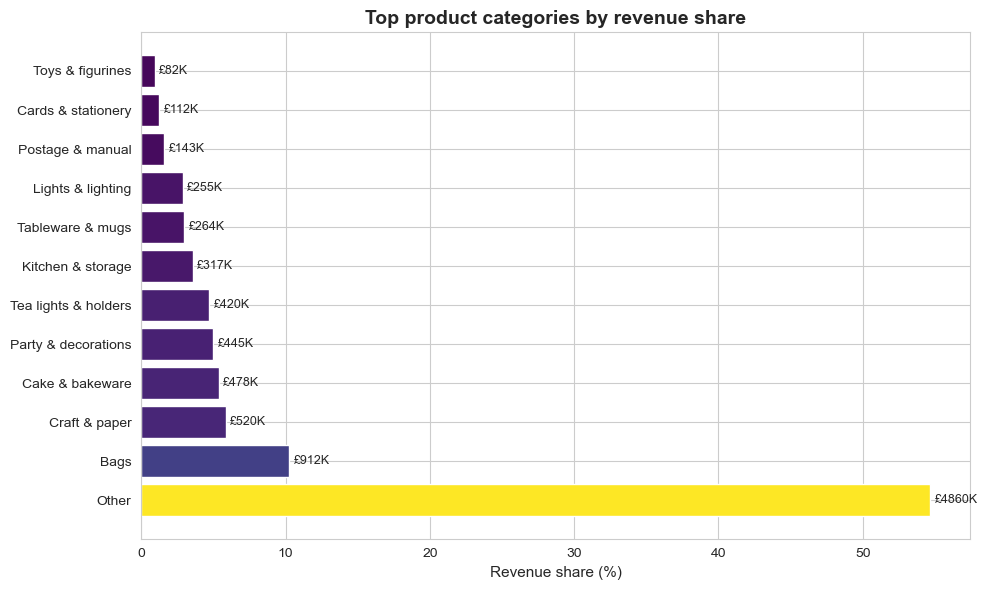

In [81]:
# Top categories by revenue share — bar chart
top_n = 12
plot_cat = cat_revenue.head(top_n)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(plot_cat))[::-1], plot_cat["RevenueSharePct"].values[::-1], color=plt.cm.viridis(plot_cat["RevenueSharePct"].values[::-1] / plot_cat["RevenueSharePct"].max()))
ax.set_yticks(range(len(plot_cat))[::-1])
ax.set_yticklabels(plot_cat["Category"].values[::-1], fontsize=10)
ax.set_xlabel("Revenue share (%)", fontsize=11)
ax.set_title("Top product categories by revenue share", fontsize=14, fontweight="bold")
ax.set_xlim(left=0)
for i, (_, row) in enumerate(plot_cat.iloc[::-1].iterrows()):
    ax.text(row["RevenueSharePct"] + 0.3, len(plot_cat) - 1 - i, f"£{row['Revenue']/1e3:.0f}K", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## Visualizations

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

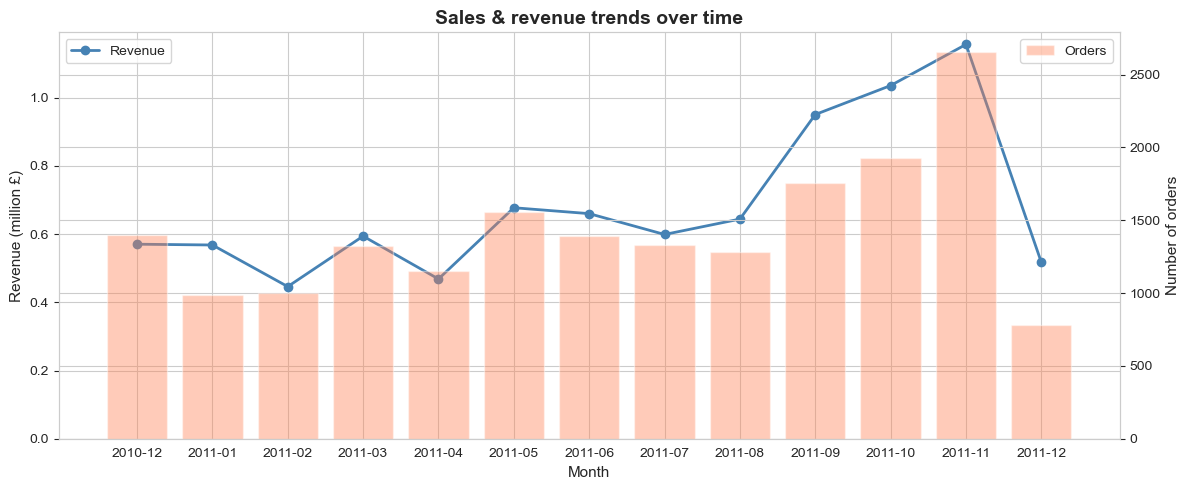

In [83]:
# 1. Monthly revenue & order count (dual-axis line)
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(trends["YearMonth"], trends["Revenue"] / 1e6, color="steelblue", linewidth=2, marker="o", markersize=6)
ax1.set_ylabel("Revenue (million £)", fontsize=11)
ax1.set_xlabel("Month", fontsize=11)
ax1.tick_params(axis="y")
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.bar(trends["YearMonth"], trends["Orders"], alpha=0.4, color="coral", label="Orders")
ax2.set_ylabel("Number of orders", fontsize=11)
ax2.tick_params(axis="y")
ax2.set_ylim(bottom=0)

plt.title("Sales & revenue trends over time", fontsize=14, fontweight="bold")
ax1.legend(["Revenue"], loc="upper left")
ax2.legend(loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

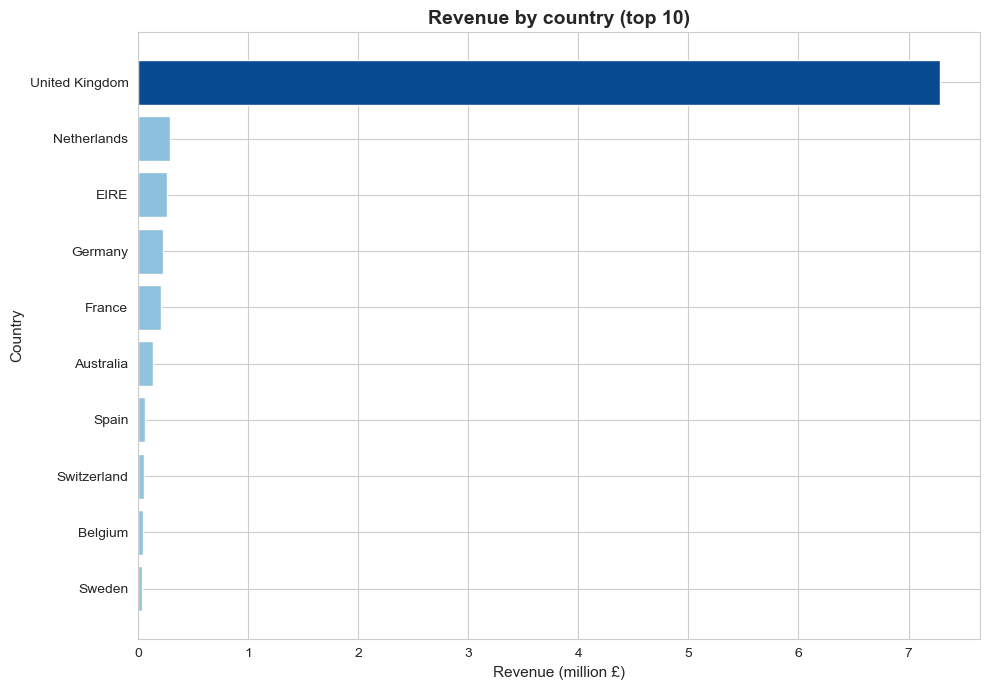

In [84]:
# 2. Revenue by country (top 15) — horizontal bar
geo_top = geo.head(10)
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(geo_top["Country"][::-1], (geo_top["Revenue"] / 1e6)[::-1], color=plt.cm.Blues(0.4 + 0.5 * (geo_top["Revenue"].values[::-1] / geo_top["Revenue"].max())))
ax.set_xlabel("Revenue (million £)", fontsize=11)
ax.set_ylabel("Country", fontsize=11)
ax.set_title("Revenue by country (top 10)", fontsize=14, fontweight="bold")
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

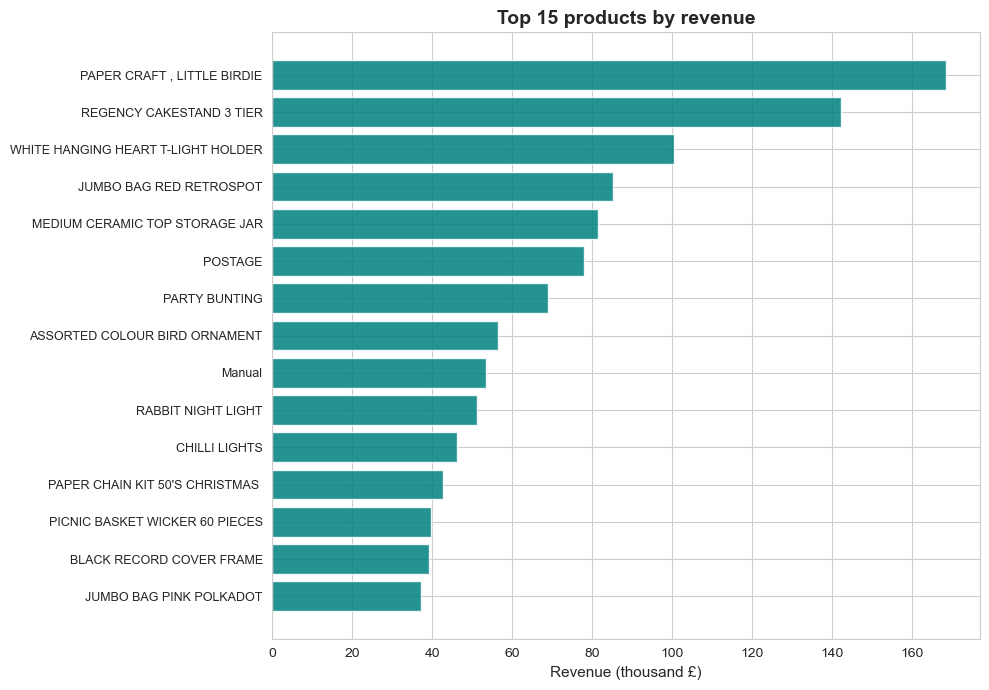

In [85]:
# 3. Top 15 products by revenue — horizontal bar
top15 = top_by_revenue.head(15).copy()
top15["ShortDesc"] = top15["Description"].str[:45] + top15["Description"].str.len().gt(45).map({True: "…", False: ""})
fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(top15))[::-1]
ax.barh(y_pos, top15["Revenue"] / 1e3, color="teal", alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(top15["ShortDesc"], fontsize=9)
ax.set_xlabel("Revenue (thousand £)", fontsize=11)
ax.set_title("Top 15 products by revenue", fontsize=14, fontweight="bold")
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

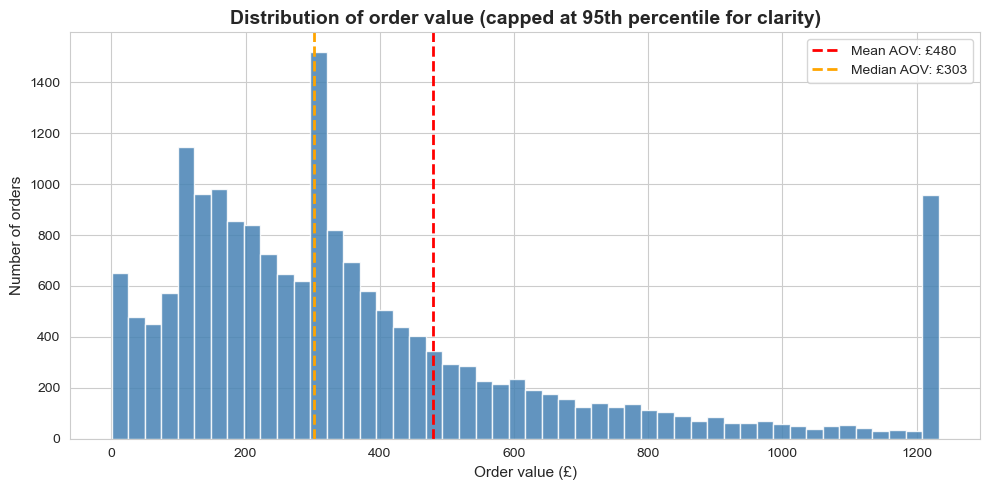

In [86]:
# 4. Average order value distribution (histogram)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(aov_overall.clip(upper=aov_overall.quantile(0.95)), bins=50, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(aov_overall.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean AOV: £{aov_overall.mean():.0f}")
ax.axvline(aov_overall.median(), color="orange", linestyle="--", linewidth=2, label=f"Median AOV: £{aov_overall.median():.0f}")
ax.set_xlabel("Order value (£)", fontsize=11)
ax.set_ylabel("Number of orders", fontsize=11)
ax.set_title("Distribution of order value (capped at 95th percentile for clarity)", fontsize=14, fontweight="bold")
ax.legend()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

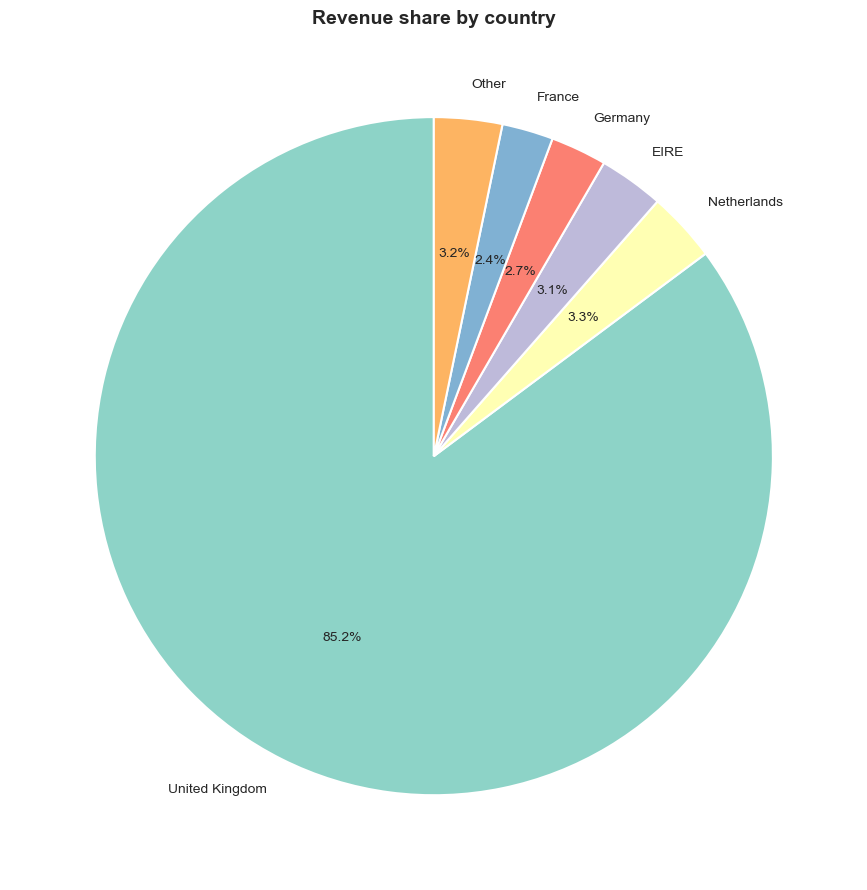

In [87]:
# 5. Geographic share of revenue — pie (top 10 + Rest of world)
geo_pie = geo.head(5).copy()
other_rev = geo["Revenue"].iloc[10:].sum()
if other_rev > 0:
    geo_pie = pd.concat([geo_pie, pd.DataFrame([{"Country": "Other", "Revenue": other_rev}])], ignore_index=True)
fig, ax = plt.subplots(figsize=(9, 9))
colors = plt.cm.Set3(range(len(geo_pie)))
wedges, labels, pct = ax.pie(geo_pie["Revenue"], labels=geo_pie["Country"], autopct="%1.1f%%", startangle=90, colors=colors)
for w in wedges:
    w.set_edgecolor("white")
    w.set_linewidth(1.5)
ax.set_title("Revenue share by country", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()